Plots: InterferometerPlotter
============================

This example illustrates how to plot an `Interferometer` dataset using an `InterferometerPlotter`.

In [1]:
%matplotlib inline
from pyprojroot import here
workspace_path = str(here())
%cd $workspace_path
print(f"Working Directory has been set to `{workspace_path}`")

from os import path
import autolens as al
import autolens.plot as aplt

/mnt/c/Users/Jammy/Code/PyAuto/autolens_workspace
Working Directory has been set to `/mnt/c/Users/Jammy/Code/PyAuto/autolens_workspace`


2021-06-09 15:54:30,878 - autoconf.conf - WARNING - Pushing new config with path /mnt/c/Users/Jammy/Code/PyAuto/PyAutoFit/autofit/config


2021-06-09 15:54:31,126 - autoconf.conf - WARNING - Pushing new config with path /mnt/c/Users/Jammy/Code/PyAuto/PyAutoGalaxy/autogalaxy/config
2021-06-09 15:54:31,344 - autoconf.conf - WARNING - Pushing new config with path /mnt/c/Users/Jammy/Code/PyAuto/PyAutoLens/autolens/config


First, lets load example interferometer of of a strong lens as an `Interferometer` object.

In [2]:
dataset_name = "mass_sie__source_sersic"
dataset_path = path.join("dataset", "interferometer", dataset_name)

real_space_mask = al.Mask2D.circular(
    shape_native=(200, 200), pixel_scales=0.05, radius=3.0
)

interferometer = al.Interferometer.from_fits(
    visibilities_path=path.join(dataset_path, "visibilities.fits"),
    noise_map_path=path.join(dataset_path, "noise_map.fits"),
    uv_wavelengths_path=path.join(dataset_path, "uv_wavelengths.fits"),
    real_space_mask=real_space_mask,
)

We now pass the interferometer to an `InterferometerPlotter` and call various `figure_*` methods to plot different 
attributes.

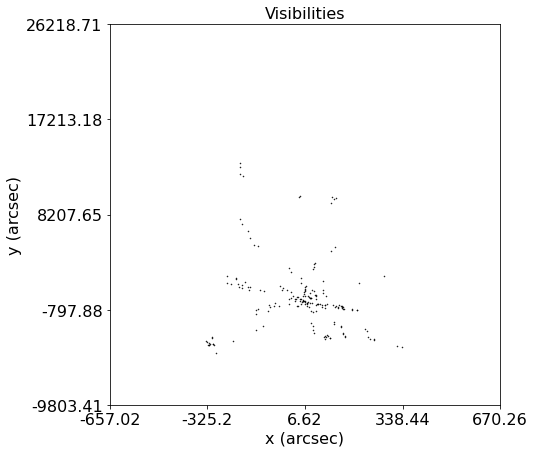

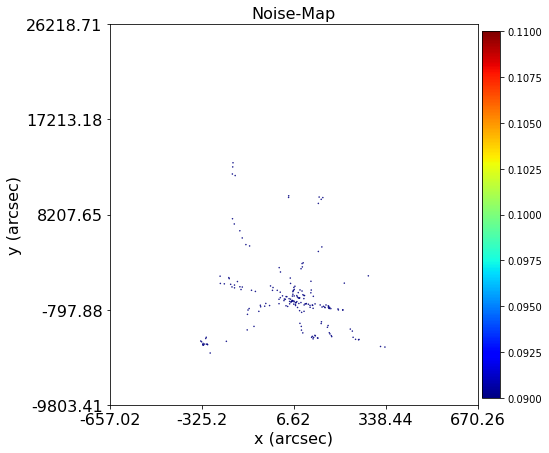

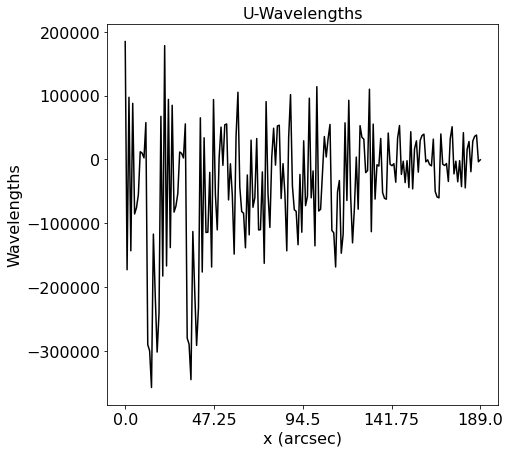

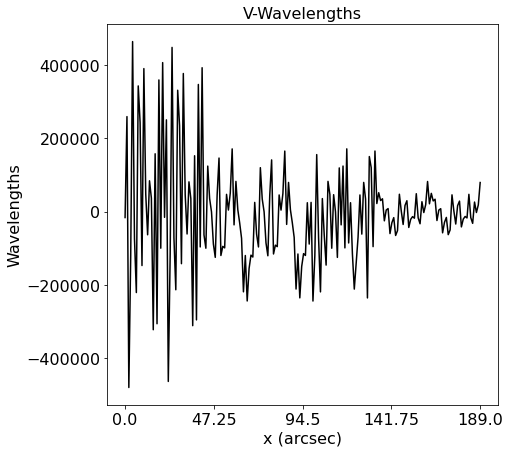

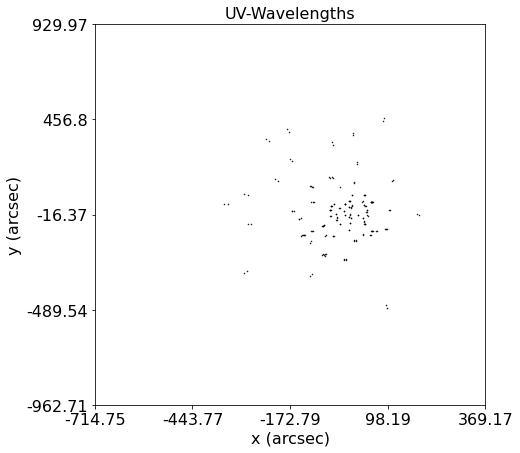

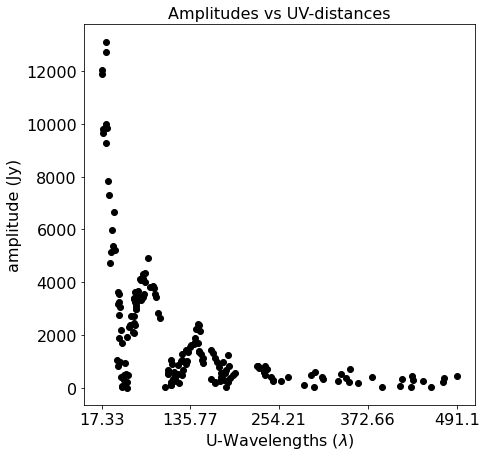

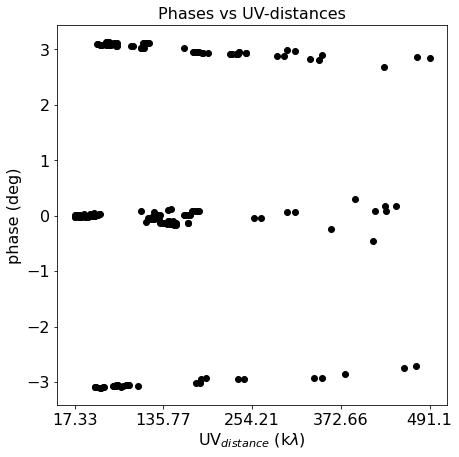

In [3]:
interferometer_plotter = aplt.InterferometerPlotter(interferometer=interferometer)
interferometer_plotter.figures_2d(
    visibilities=True,
    noise_map=True,
    u_wavelengths=True,
    v_wavelengths=True,
    uv_wavelengths=True,
    amplitudes_vs_uv_distances=True,
    phases_vs_uv_distances=True,
)

The `InterferometerPlotter` may also plot a subplot of all of these attributes.

/mnt/c/Users/Jammy/Code/PyAuto/PyAutoArray/autoarray/plot/mat_wrap/mat_plot.py:178: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(rows, columns, self.subplot_index)


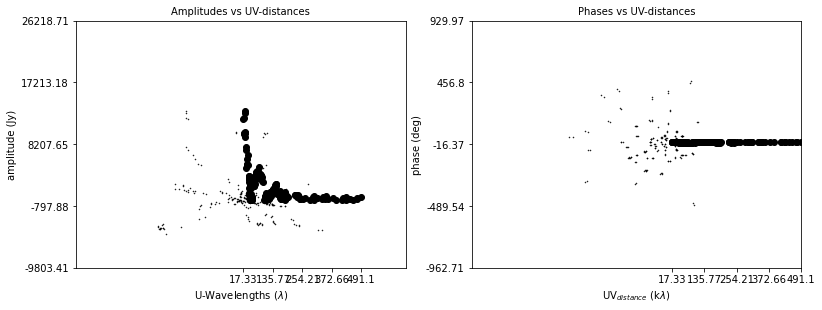

In [4]:
interferometer_plotter.subplot_interferometer()

The dirty images of the interferometer dataset can also be plotted, which use the transformer of the interferometer 
to map the visibilities, noise-map or other quantity to a real-space image.

/home/jammy/venvs/PyAuto/lib/python3.8/site-packages/pynufft/linalg/nufft_cpu.py:381: ComplexWarning: Casting complex values to real discards the imaginary part
  xx.ravel()[self.NdCPUorder * self.batch + bat] = k.ravel()[


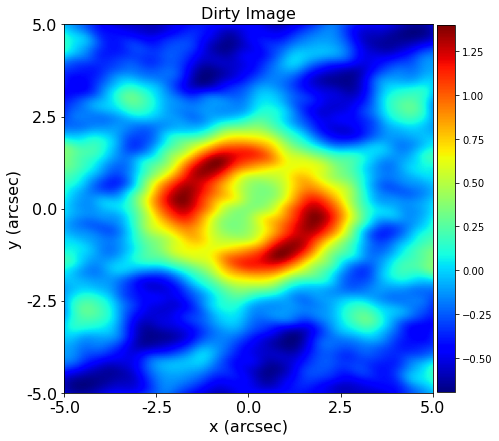

/home/jammy/venvs/PyAuto/lib/python3.8/site-packages/pynufft/linalg/nufft_cpu.py:381: ComplexWarning: Casting complex values to real discards the imaginary part
  xx.ravel()[self.NdCPUorder * self.batch + bat] = k.ravel()[


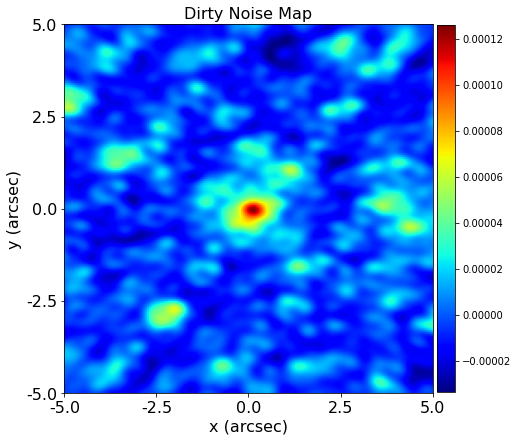

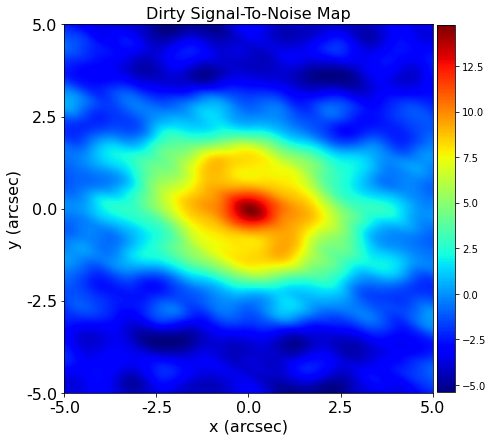

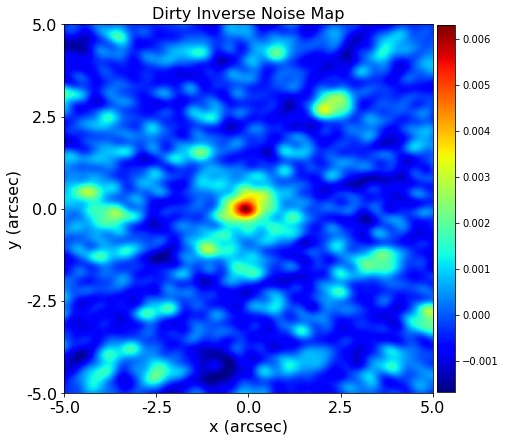

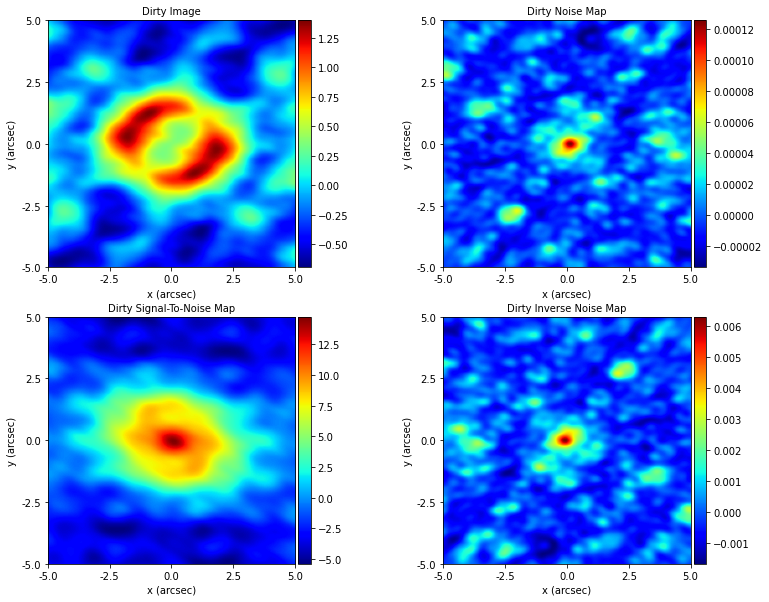

In [5]:
interferometer_plotter.figures_2d(
    dirty_image=True,
    dirty_noise_map=True,
    dirty_signal_to_noise_map=True,
    dirty_inverse_noise_map=True,
)
interferometer_plotter.subplot_dirty_images()

The `Interferometer` contains the following attributes which can be plotted automatically via the `Include2D` object.

/mnt/c/Users/Jammy/Code/PyAuto/PyAutoArray/autoarray/plot/mat_wrap/mat_plot.py:178: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(rows, columns, self.subplot_index)


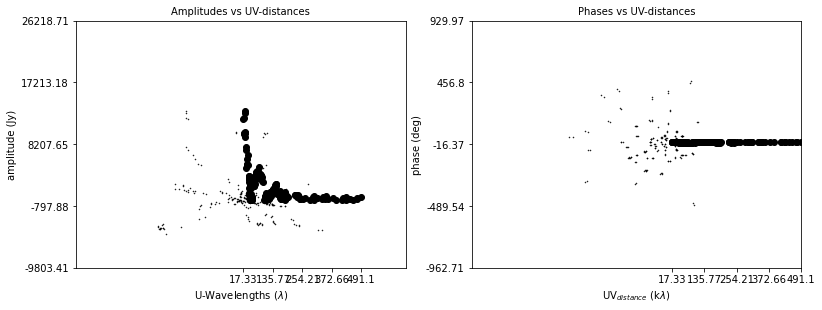

In [6]:
include_2d = aplt.Include2D()
interferometer_plotter = aplt.InterferometerPlotter(
    interferometer=interferometer, include_2d=include_2d
)
interferometer_plotter.subplot_interferometer()

Finish.